# <center>Data Wrangling and Exploratory Data Analysis in Python</center>
## <center><em>By Asuvila Marion</em></center>

**[Click here to access the dataset](https://www.kaggle.com/datasets/walekhwatlphilip/intro-to-data-cleaning-eda-and-machine-learning?select=intro-to-data-cleaning-eda-and-machine-learnin.html)**

This project focuses on preparing and exploring a student dataset to uncover insights and ensure data quality. The dataset contains information such as names, ages, genders, countries, residence types, entry exam scores, previous education levels, study hours, and Python exam scores.

# Objectives

**Data Cleaning**:

1. Standardize column names to lowercase.

2. Correct typos and inconsistencies in categorical variables.

3. Unify variations in residence types.

4. Standardize gender entries.

5. Handle missing values in numerical columns by using appropriate imputation methods.

**Exploratory Data Analysis (EDA)**:

1. Examine the distribution of numerical and categorical features.

2. Identify patterns, trends, and correlations between variables.

3. Detect outliers and anomalies in the dataset.

**Tools and Libraries**

Python with libraries: `pandas`, `numpy`, `matplotlib`)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r"C:\Users\Work Force\Desktop\Data analytics notes\PROJECTS\Python\bi.csv")
#inspecting the data
print(df.shape)

print(df.info())
df.head()

(77, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     object 
 1   lNAME          77 non-null     object 
 2   Age            77 non-null     int64  
 3   gender         77 non-null     object 
 4   country        77 non-null     object 
 5   residence      77 non-null     object 
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     object 
 8   studyHOURS     77 non-null     int64  
 9   Python         75 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.7+ KB
None


,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


#  Data Cleaning Issues and Fixes

The dataset has several inconsistencies that need to be addressed for proper analysis:

## 1. Column Names
Columns are inconsistent in casing: example; `entryExam`.  
Action: Rename columns using a consistent naming e.g, (first_name, entry_exam, study_hourse)

## 2. Gender Column
Inconsistent values: `F`, `Female`, `female`.  
Action: Standardize to **Male, Female**.

## 3. Country Name Inconsistencies
Examples:
`Norge` → `Norway`  
`RSA` → `South Africa`  
`UK → `United Kingdom`
Action: Map all variations to std country names.

## 4. Residence Type Variations
Examples:
`BI-Residence`, `BIResidence`, `BI_Residence`  
Actioify to **BI Residence**.

## 5. Education Level Issues
Typos and inconsistent casing:  
`Barrrchelors` → `Bachelor`  
`DIPLOMA`, `Diplomaaa` → `Diploma`

Action: Standardize to **Bachelor, Diploma**.

## 7. Missing Values
**Python subject scores** have missing values.  

Action: Fill `NaN` values using column mean or a suitable imputation strategy

In [5]:
# renaming the cols
df.rename(columns=
    {
        'fNAME':'first_name',
        'lNAME':'last_name',
        'Age':'age',
        'entryEXAM':'entry_exam',
        'prevEducation':'prev_education',
        'studyHOURS':'study_hours'
    }, inplace =True
)

In [6]:
#going col by col
df['first_name']=df['first_name'].str.capitalize()
df['last_name']= df['last_name'].str.capitalize()

In [7]:
df['gender']=df['gender'].replace({
    'M':'Male',
    'F':'Female',
}).str.capitalize()

In [8]:
df['country']= df['country'].replace({
    'Norge':'Norway',
    'Rsa':'South Africa',
    'Somali':'Somalia',
    'UK':'United Kingdom'}).str.title()

In [9]:
df['residence']= df['residence'].str.replace(r'BI-Residence|BIResidence|BI_Residence','BI Residence', regex=True)

In [10]:
df['prev_education'] = df['prev_education'].replace({
    'HighSchool':'High School',
    'Barrrchelors':'Bachelors',
    'Diplomaaa':'Diploma'
}).str.title()

In [11]:
# null values
df.isna().sum()

first_name        0
last_name         0
age               0
gender            0
country           0
residence         0
entry_exam        0
prev_education    0
study_hours       0
Python            2
DB                0
dtype: int64

In [12]:
df['Python']=df['Python'].fillna(df['Python'].mean())

In [13]:
df['Python'] = df['Python'].round(1)

In [14]:
# dataset info
df.dtypes

first_name         object
last_name          object
age                 int64
gender             object
country            object
residence          object
entry_exam          int64
prev_education     object
study_hours         int64
Python            float64
DB                  int64
dtype: object

In [15]:
#data is clean and ready for analysis
df.head() 

,first_name,last_name,age,gender,country,residence,entry_exam,prev_education,study_hours,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,Male,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,High School,130,74.0,50
3,Shoni,Hlongwane,22,Female,South Africa,Sognsvann,40,High School,120,75.9,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [16]:
# df.to_csv("cleaned_bi.csv",index= False)

## EDA

In [18]:
df.describe()

,age,entry_exam,study_hours,Python,DB
count,77.000000,77.000000,77.000000,77.000000,77.000000
mean,35.207792,76.753247,149.714286,75.854545,69.467532
std,10.341966,16.475784,12.743272,15.206210,17.033701
min,21.000000,28.000000,114.000000,15.000000,30.000000
25%,27.000000,69.000000,144.000000,72.000000,56.000000
50%,33.000000,80.000000,156.000000,81.000000,71.000000
75%,42.000000,90.000000,158.000000,85.000000,83.000000
max,71.000000,98.000000,160.000000,91.000000,100.000000


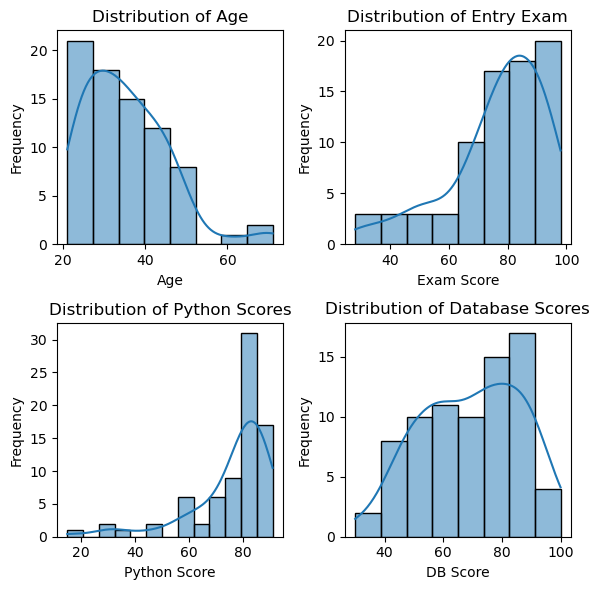

In [46]:

fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharex=False)
axes = axes.flatten()
sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

sns.histplot(df['entry_exam'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Entry Exam')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Frequency')
             
sns.histplot(df['Python'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Python Scores')
axes[2].set_xlabel('Python Score')
axes[2].set_ylabel('Frequency')

sns.histplot(df['DB'], kde=True, ax=axes[3])
axes[3].set_title('Distribution of Database Scores')
axes[3].set_xlabel('DB Score')
axes[3].set_ylabel('Frequency')             
plt.tight_layout()
plt.show()


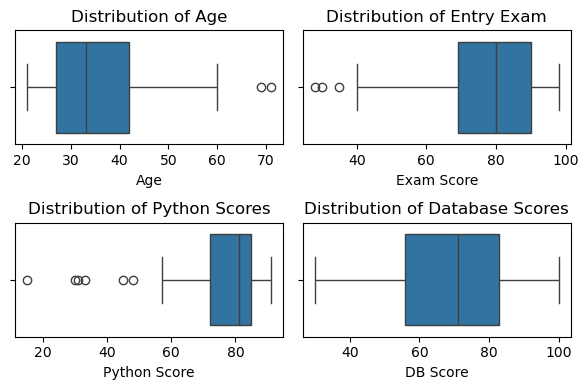

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4))
axes = axes.flatten()

sns.boxplot(x=df['age'], ax=axes[0], orient='h')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')


sns.boxplot(x=df['entry_exam'], ax=axes[1], orient='h')
axes[1].set_title('Distribution of Entry Exam')
axes[1].set_xlabel('Exam Score')

             
sns.boxplot(x=df['Python'], ax=axes[2], orient='h')
axes[2].set_title('Distribution of Python Scores')
axes[2].set_xlabel('Python Score')


sns.boxplot(x=df['DB'], ax=axes[3], orient='h')
axes[3].set_title('Distribution of Database Scores')
axes[3].set_xlabel('DB Score')
           

plt.tight_layout()
plt.show()



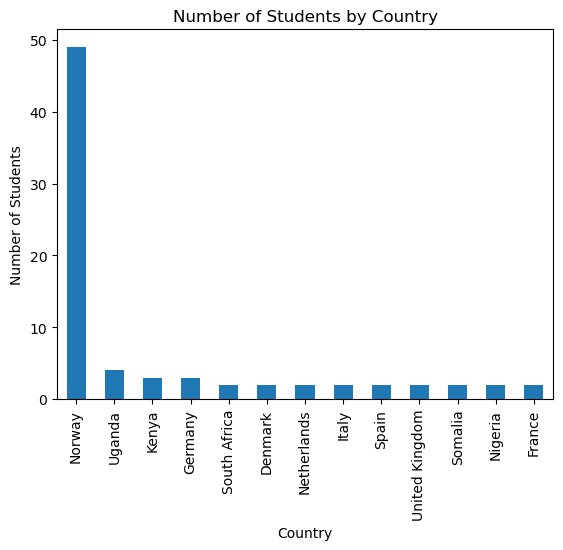

In [21]:
#students by country
stu_country = df['country'].value_counts()
stu_country.plot(kind='bar')
plt.title('Number of Students by Country')
plt.xlabel('Country')
plt.ylabel('Number of Students')
plt.show()

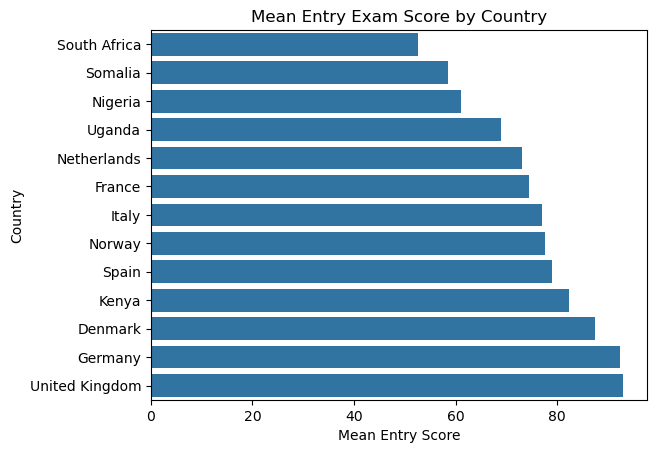

In [22]:
# mean entry exam score by country
country_mean = df.groupby(['country'])['entry_exam'].mean().reset_index()
country_mean.sort_values(by='entry_exam', inplace=True)
sns.barplot(data=country_mean, x='entry_exam', y='country')

plt.title('Mean Entry Exam Score by Country')
plt.xlabel('Mean Entry Score')
plt.ylabel('Country')
plt.show()